## NOTE: scipy and seaborn have to be installed separately of the CNSistent environment

In [9]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import matplotlib.pyplot as plt
import numpy as np

import cns
import cns.data_utils as cdu
import seaborn as sns
from scipy import stats

In [11]:
# set font size to 12
plt.rcParams.update({'font.size': 10})
color_map = plt.cm.get_cmap('tab10').colors[:10]

C:\Users\adams\AppData\Local\Temp\ipykernel_32424\796581361.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [12]:
samples_df, cns_df = cdu.main_load(segment_type = "1MB", use_filter=True, print_info=True);
samples_df["ploidy"] = samples_df["ploidy_major_cn"] + samples_df["ploidy_minor_cn"]
samples_df["ploidy_diff"] = samples_df["ploidy_major_cn"] + samples_df["ploidy_minor_cn"] - 2

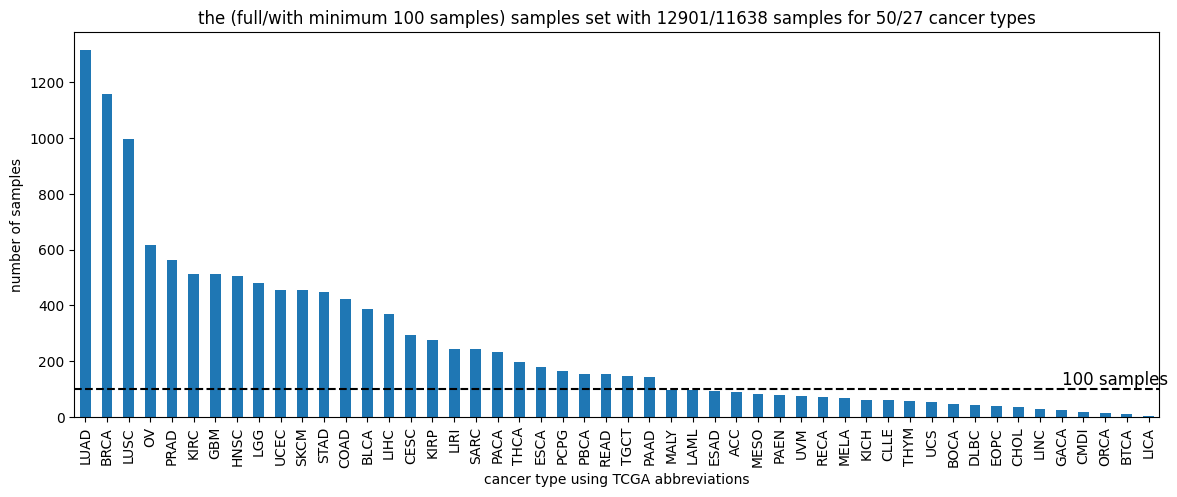

In [13]:
threshold = 100
subset_df = cdu.samples_above_threshold(samples_df, threshold)
samples_df["type"].value_counts().plot(kind="bar")
type_count = len(samples_df["type"].unique())
count_subset = subset_df["type"].value_counts().shape[0]
plt.title(f"the (full/with minimum {threshold} samples) samples set with {len(samples_df)}/{len(subset_df)} samples for {type_count}/{count_subset} cancer types")
plt.ylabel("number of samples")
plt.xlabel("cancer type using TCGA abbreviations")
plt.gcf().set_size_inches(14, 5)
# add a horizontal line at 50 samples
plt.axhline(y=threshold, color='black', linestyle='--')
# add a label to the line
plt.text(45, threshold, f'{threshold} samples', color = 'black', fontsize = 12, va = 'bottom')

cdu.save_cns_fig("cancer_types")

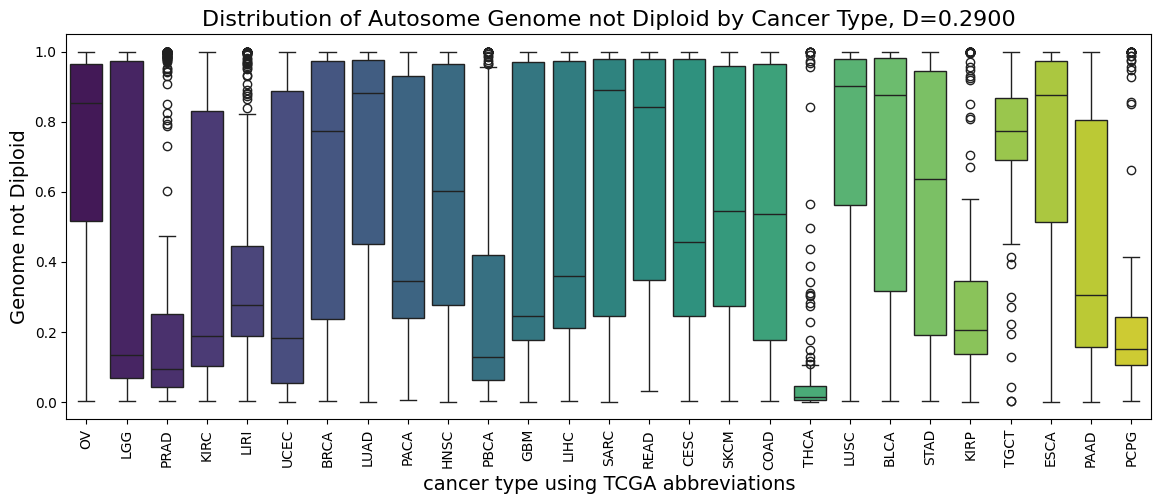

In [14]:
def discrimination_ratio(samples_df, statistic, group_col="type"):
    # Calculate mean for each group
    group_means = samples_df.groupby(group_col)[statistic].mean()
    # Calculate overall mean
    overall_mean = samples_df[statistic].mean()
    # Between-group variance
    between_var = ((group_means - overall_mean) ** 2).mean()
    # Within-group variance
    within_var = samples_df.groupby(group_col)[statistic].var().mean()
    # Discrimination ratio
    if within_var == 0:
        return np.nan
    return between_var / within_var


def plot_statistic(samples_df, statistic):
        # Calculate eta-squared (η²) for 'type' (categorical) and 'breaks_total_cn_aut' (numeric) using one-way ANOVA
    plt.figure(figsize=(14, 5))
    ax = sns.boxplot(
        data=samples_df,
        x='type',
        y=statistic,
        hue='type',
        palette='viridis',
        legend=False
    )
    plt.xlabel('cancer type using TCGA abbreviations', fontsize=14)
    plt.xticks(rotation=90)

# Customize the plot
plot_statistic(subset_df, 'ane_any_aut')
ratio = discrimination_ratio(subset_df, 'ane_any_aut')
plt.title(f'Distribution of Autosome Genome not Diploid by Cancer Type, D={ratio:.4f}', fontsize=16)
plt.ylabel('Genome not Diploid', fontsize=14)
cdu.save_cns_fig("ane_per_type_boxplot")


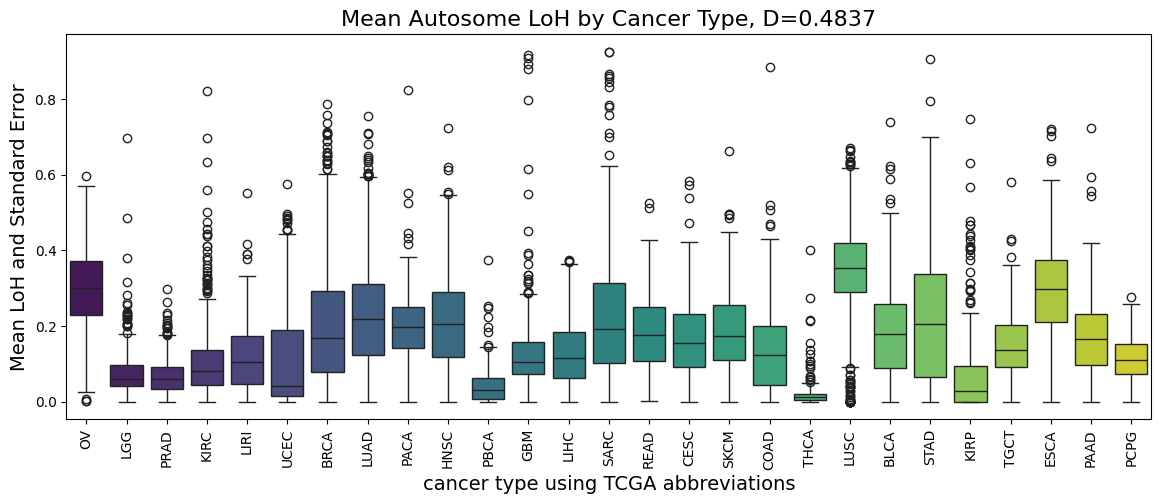

In [15]:
# Customize the plot
plot_statistic(subset_df, 'loh_any_aut')
ratio_loh = discrimination_ratio(subset_df, 'loh_any_aut')
plt.title(f'Mean Autosome LoH by Cancer Type, D={ratio_loh:.4f}', fontsize=16)
plt.ylabel('Mean LoH and Standard Error', fontsize=14)
cdu.save_cns_fig("loh_per_type_boxplot")

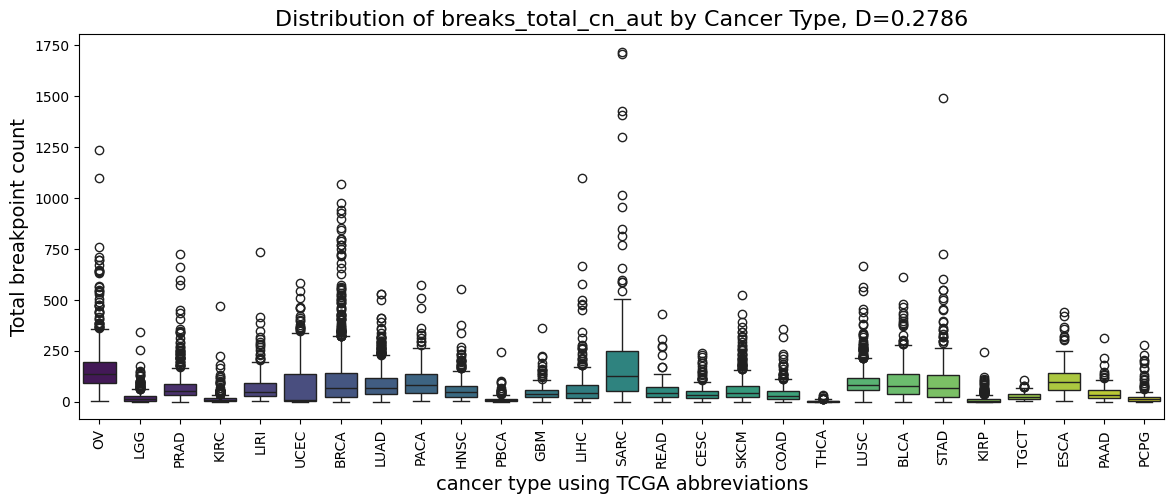

In [16]:
plot_statistic(subset_df, 'breaks_total_cn_aut')
ratio_breaks = discrimination_ratio(subset_df, 'breaks_total_cn_aut')
plt.title(f'Distribution of breaks_total_cn_aut by Cancer Type, D={ratio_breaks:.4f}', fontsize=16)
plt.ylabel('Total breakpoint count', fontsize=14)
cdu.save_cns_fig("breaks_total_cn_aut_per_type")

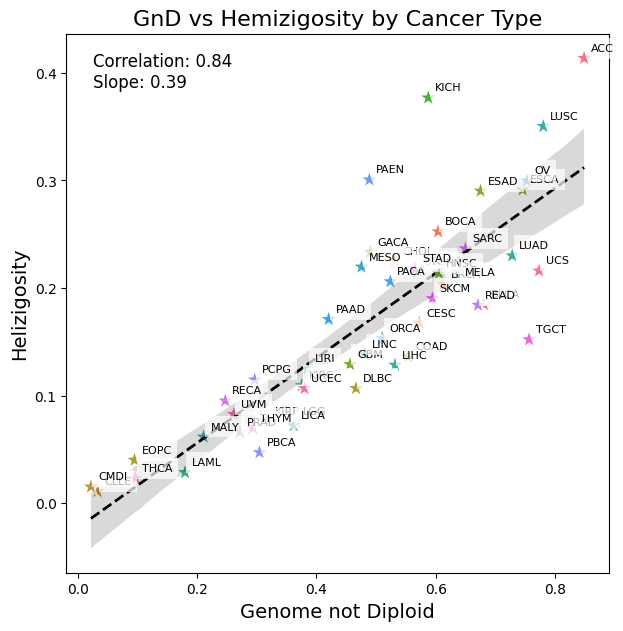

In [17]:
def corr_plot(statistic1, statistic2):
# Create scatter plot of aneuploidy vs LOH by cancer type
    plt.figure(figsize=(7, 7))
    # Calculate mean values for each type
    means = samples_df.groupby('type')[[statistic1, statistic2]].mean()

    # Add mean values as larger points
    sns.scatterplot(
        data=means.reset_index(),
        x=statistic1,
        y=statistic2,
        hue='type',
        s=200,
        marker='*',
        legend=False
    )

    # Add linear regression line
    regplot = sns.regplot(
        data=means,
        x=statistic1,
        y=statistic2,
        scatter=False,
        line_kws={'color': 'black', 'linestyle': '--', 'lw': 2}
    )

    # Calculate slope of the regression line
    slope = np.polyfit(means[statistic1], means[statistic2], 1)[0]

    # Add labels for mean values
    for idx, row in means.iterrows():
        plt.annotate(
            idx,  # cancer type label
            (row[statistic1], row[statistic2]),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
        )


    # Add correlation coefficient
    corr = means[statistic1].corr(means[statistic2])
    plt.text(
        0.05, 0.9,
        f'Correlation: {corr:.2f}\nSlope: {slope:.2f}',
        transform=plt.gca().transAxes,
        fontsize=12
    )

# Customize the plot
corr_plot('ane_any_aut', 'loh_any_aut')
plt.title('GnD vs Hemizigosity by Cancer Type', fontsize=16)
plt.xlabel('Genome not Diploid', fontsize=14)
plt.ylabel('Helizigosity', fontsize=14)
cdu.save_cns_fig("ane_any_aut_vs_loh_any_aut")

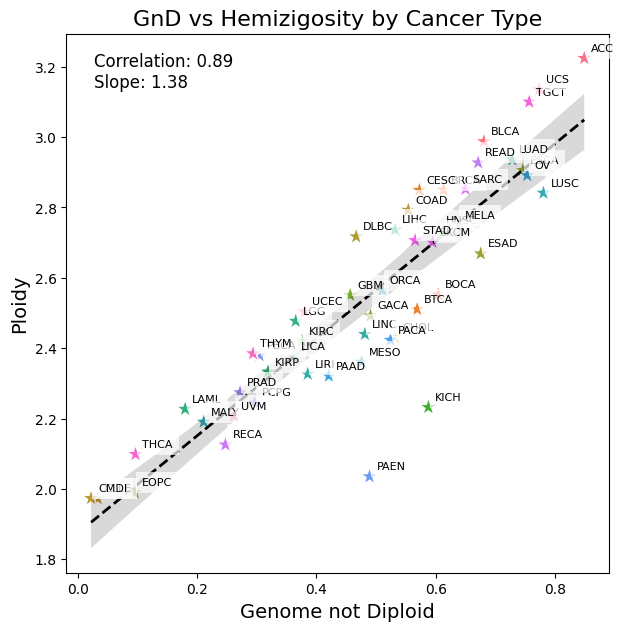

In [18]:
corr_plot('ane_any_aut', 'ploidy')
plt.title('GnD vs Hemizigosity by Cancer Type', fontsize=16)
plt.xlabel('Genome not Diploid', fontsize=14)
plt.ylabel('Ploidy', fontsize=14)
cdu.save_cns_fig("ane_any_aut_vs_ploidy")

In [19]:
top_6 = samples_df["type"].value_counts().head(6).index
subsample = {cancer_type: cns.add_total_cn(cns.group_samples(cns.select_cns_by_type(cns_df, samples_df, cancer_type))) for cancer_type in top_6}

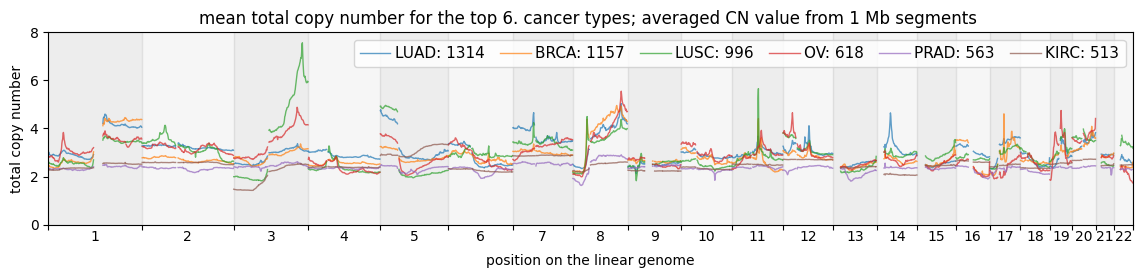

In [20]:
fig, ax = plt.subplots(figsize=(14, 2.5))
cns.plot_chr_bg(ax, y_max=8)
colors = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, 6))
for i, cancer_type in enumerate(top_6):
	sub_df = subsample[cancer_type]
	sample_count = len(samples_df[samples_df["type"] == cancer_type])
	cns.plot_lines(ax, cns.only_aut(sub_df), cn_column="total_cn", label=f"{cancer_type}: {sample_count}" , color=color_map[i], alpha=0.7)
cns.plot_x_ticks(ax)
plt.ylabel("total copy number")
plt.xlabel("position on the linear genome")
ax.set_xlim(0, cns.hg19.aut_len)
ax.legend(ncol=6, loc='upper right', bbox_to_anchor=(1, 1), fontsize=11, handletextpad=0.3, columnspacing=1)

plt.title(f"mean total copy number for the top 6. cancer types; averaged CN value from 1 Mb segments ")
cdu.save_cns_fig("top_6_profiles")

Text(0.5, 1.0, 'mean total copy number for 40 types with at least 50 samples')

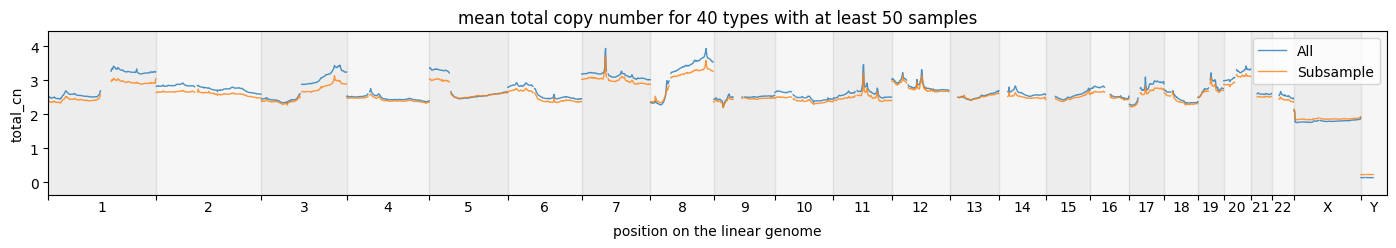

In [21]:
above_50 = samples_df["type"].value_counts().where(lambda x: x >= 50).where(lambda x: x != "Other").dropna().index.values
all_samples = samples_df.query("type in @above_50")
sub_samples = all_samples.reset_index().groupby('type').apply(lambda x: x.sample(n=50, random_state=0), include_groups=False).set_index("sample_id")
# select only 50 samples for each type to obtain balanced mean
sel_dict = { "All": all_samples, "Subsample": sub_samples }
sel_df = cns.pd.concat([cns.add_total_cn(cns.group_samples(cns.select_CNS_samples(cns_df, v), group_name=k)) for k, v in sel_dict.items()])
cns.fig_lines(sel_df, cn_columns="total_cn")
plt.gcf().set_size_inches(14, 2)
plt.title(f"mean total copy number for {len(above_50)} types with at least 50 samples")